# RFS Classification

## DenseNet 모델 학습부터 TFLite 변환까지 전체 과정 10줄 요약

1. 이미지 폴더에서 가위·바위·보 데이터를 읽어와 `64×64×3` 크기의 숫자 배열로 변환한다.

2. 폴더 번호를 기준으로 각 이미지에 `0, 1, 2` 정답 라벨을 붙이고 학습용 데이터와 테스트용 데이터로 나눈다.

3. ImageNet으로 미리 학습된 DenseNet121을 불러와 이미지 특징을 추출하는 전이학습 모델을 만든다.

4. DenseNet의 원래 1000개 분류기는 제거하고, 가위·바위·보 3개 클래스를 분류하는 Softmax 출력층을 새로 붙인다.

5. `compile()`에서 Adam 최적화 방법, 정수형 다중분류용 손실함수, 정확도 평가 기준을 설정한다.

6. `ModelCheckpoint`를 사용해 학습 중 검증 손실값이 가장 낮은 best Keras 모델만 `.keras` 파일로 저장한다.

7. `model.fit()`으로 30 epoch 동안 학습하고, 학습 정확도·검증 정확도·손실값 변화를 `history`에 저장한다.

8. 학습 그래프를 통해 정확도는 올라가는지, 손실값은 내려가는지, 과적합이 생기는지 확인한다.

9. 저장된 best `.keras` 모델을 다시 불러와 TensorFlow Lite 변환기로 `.tflite` 모델을 만든다.

10. 변환 전 Keras 모델과 변환 후 TFLite 모델의 크기와 시간을 비교하여 배포용 모델이 제대로 생성되었는지 확인한다.

## 모듈 로딩

In [2]:
import sys
print(sys.executable)

c:\Users\ndong\OneDrive\AI_Practice_2026_1\week14\venv_tf215\Scripts\python.exe


In [1]:
import tensorflow as tf
import tensorflow_model_optimization as tfmot

print(tf.__version__)
print(tfmot.__version__)


2.15.0
0.8.0


In [2]:
import os

os.environ.pop("TF_USE_LEGACY_KERAS", None)

import tensorflow as tf
import tensorflow_model_optimization as tfmot

print("SUCCESS")

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import glob
import cv2
from sklearn.model_selection import train_test_split

print(tf.__file__)
print(tf.__version__)
print(tf.__spec__)
print(tf.__path__)
print("NumPy Version :{}".format(np.__version__))
print("TensorFlow Version :{}".format(tf.__version__))
print("Matplotlib Version :{}".format(plt.matplotlib.__version__))

SUCCESS
c:\Users\ndong\OneDrive\AI_Practice_2026_1\week14\venv_tf215\lib\site-packages\tensorflow\__init__.py
2.15.0
ModuleSpec(name='tensorflow', loader=<_frozen_importlib_external.SourceFileLoader object at 0x000001754D31C4C0>, origin='c:\\Users\\ndong\\OneDrive\\AI_Practice_2026_1\\week14\\venv_tf215\\lib\\site-packages\\tensorflow\\__init__.py', submodule_search_locations=['c:\\Users\\ndong\\OneDrive\\AI_Practice_2026_1\\week14\\venv_tf215\\lib\\site-packages\\tensorflow', 'c:\\Users\\ndong\\OneDrive\\AI_Practice_2026_1\\week14\\venv_tf215\\lib\\site-packages\\tensorflow\\_api\\v2'])
['c:\\Users\\ndong\\OneDrive\\AI_Practice_2026_1\\week14\\venv_tf215\\lib\\site-packages\\keras\\api\\_v2', 'c:\\Users\\ndong\\OneDrive\\AI_Practice_2026_1\\week14\\venv_tf215\\lib\\site-packages\\keras\\_tf_keras', 'c:\\Users\\ndong\\OneDrive\\AI_Practice_2026_1\\week14\\venv_tf215\\lib\\site-packages\\tensorflow_estimator\\python\\estimator\\api\\_v2', 'c:\\Users\\ndong\\OneDrive\\AI_Practice_2026_1\

## g-drive 마운트

In [3]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('g-drive mounted.')
    colab=True
except:
    print('local drive.')
    colab =False

local drive.


## RPS 데이터셋 준비

In [4]:
# files_path: 다른 경로에 실습파일을 복사했다면, 아래 경로를 수정하세요

if colab :
  !unzip -q -o /content/drive/MyDrive/files/RPS_Dataset.zip
  files_path = '/content/RPS_Dataset'
else :
  files_path = 'C:/Users/ndong/OneDrive/AI_Practice_2026_1/week14/RP2.CNN02-main/RP2.CNN02-main/RPS_Dataset'

In [5]:
files_path = "C:/Users/ndong/OneDrive/AI_Practice_2026_1/week14/RP2.CNN02-main/RP2.CNN02-main/RPS_Dataset"

In [6]:
for ind in range(3):
      path = files_path + "/" + str(ind) + "/*.*"
      files = glob.glob(path)
      print(ind, len(files), path)

0 903 C:/Users/ndong/OneDrive/AI_Practice_2026_1/week14/RP2.CNN02-main/RP2.CNN02-main/RPS_Dataset/0/*.*
1 907 C:/Users/ndong/OneDrive/AI_Practice_2026_1/week14/RP2.CNN02-main/RP2.CNN02-main/RPS_Dataset/1/*.*
2 907 C:/Users/ndong/OneDrive/AI_Practice_2026_1/week14/RP2.CNN02-main/RP2.CNN02-main/RPS_Dataset/2/*.*


## 폴더 별로 파일 읽어 데이터화 진행

In [7]:
%%time
# 위 코드는 Jupyter Notebook / Colab에서만 사용하는 명령어입니다.
# 이 셀 전체가 실행되는 데 걸린 시간을 측정해 줍니다.


# first는 첫 번째 클래스 데이터를 처리하는지 확인하기 위한 변수입니다.
# 첫 번째 데이터는 train_data, test_data를 새로 만들고,
# 두 번째 클래스부터는 기존 데이터 뒤에 이어 붙여야 하기 때문입니다.
first = True


# 모든 이미지를 64 x 64 크기로 통일합니다.
# CNN 모델에 넣으려면 모든 이미지의 가로, 세로 크기가 같아야 합니다.
IMG_SIZE = 64


# ind는 클래스 번호입니다.
# range(0, 3, 1)은 0, 1, 2를 의미합니다.
# 즉, 0번 폴더, 1번 폴더, 2번 폴더를 차례대로 읽습니다.
# 예를 들어 가위바위보 데이터라면
# 0 = rock, 1 = scissors, 2 = paper 처럼 사용할 수 있습니다.
for ind in range(0, 3, 1):


    # files_path 아래에 있는 0, 1, 2 폴더 안의 모든 파일 경로를 만듭니다.
    # 예: files_path가 "/content/data"라면
    # ind가 0일 때 path는 "/content/data/0/*.*"가 됩니다.
    # *.* 는 폴더 안의 모든 파일을 의미합니다.
    path = files_path + '/' + str(ind) + '/*.*'


    # 현재 읽고 있는 폴더 경로를 출력합니다.
    # 어떤 폴더의 이미지를 읽는 중인지 확인하기 위한 코드입니다.
    print(path)


    # glob.glob(path)는 path 조건에 맞는 모든 파일 경로를 리스트로 가져옵니다.
    # 예: ["data/0/img1.jpg", "data/0/img2.jpg", ...]
    files = glob.glob(path)


    # files에 들어 있는 이미지 파일들을 하나씩 읽어서 숫자 배열로 변환합니다.
    tmpx = np.array([

        # cv2.resize(..., (IMG_SIZE, IMG_SIZE))
        # 이미지를 64 x 64 크기로 줄이거나 늘립니다.
        # 딥러닝 모델은 입력 크기가 같아야 하므로 반드시 크기를 통일해야 합니다.
        cv2.resize(

            # cv2.cvtColor(..., cv2.COLOR_BGR2RGB)
            # OpenCV는 이미지를 기본적으로 BGR 순서로 읽습니다.
            # 하지만 일반적인 이미지 처리나 matplotlib에서는 RGB 순서를 사용합니다.
            # 그래서 BGR을 RGB로 바꿔 줍니다.
            cv2.cvtColor(

                # cv2.imread(x, cv2.IMREAD_COLOR)
                # x는 이미지 파일 경로입니다.
                # 해당 경로에 있는 이미지를 컬러 이미지로 읽어옵니다.
                cv2.imread(x, cv2.IMREAD_COLOR),

                # BGR 색상 순서를 RGB 색상 순서로 변환합니다.
                cv2.COLOR_BGR2RGB
            ),

            # 이미지를 64 x 64 크기로 맞춥니다.
            (IMG_SIZE, IMG_SIZE)
        )

        # files 리스트에 있는 이미지 경로 x를 하나씩 꺼내서 위 작업을 반복합니다.
        for x in files
    ])


    # tmpy는 현재 이미지들의 정답 라벨입니다.
    # 현재 ind가 0이면, 이 폴더의 모든 이미지 라벨은 0입니다.
    # 현재 ind가 1이면, 이 폴더의 모든 이미지 라벨은 1입니다.
    # 현재 ind가 2이면, 이 폴더의 모든 이미지 라벨은 2입니다.
    #
    # len(files)는 현재 폴더 안의 이미지 개수입니다.
    # 예를 들어 0번 폴더에 이미지가 100장 있으면
    # tmpy = [0, 0, 0, ..., 0] 형태가 됩니다.
    tmpy = np.array([ind] * len(files))


    # 현재 클래스의 이미지 데이터 tmpx와 라벨 tmpy를
    # 학습용 데이터와 테스트용 데이터로 나눕니다.
    #
    # test_size=0.2는 전체 데이터 중 20%를 테스트용으로 사용한다는 뜻입니다.
    # 나머지 80%는 학습용으로 사용합니다.
    #
    # random_state=123은 데이터를 섞는 기준을 고정하는 값입니다.
    # 이 값을 고정하면 코드를 다시 실행해도 같은 방식으로 데이터가 나뉩니다.
    xtrain, xtest, ytrain, ytest = train_test_split(
        tmpx,
        tmpy,
        test_size=0.2,
        random_state=123
    )


    # 첫 번째 클래스 데이터를 처리할 때입니다.
    # 아직 train_data, test_data가 없으므로 새로 만들어야 합니다.
    if first == True:


        # 첫 번째 클래스의 학습 이미지를 train_data에 저장합니다.
        # copy()를 사용해서 원본 xtrain과 독립된 복사본을 만듭니다.
        train_data = xtrain.copy()


        # 첫 번째 클래스의 학습 라벨을 train_labels에 저장합니다.
        train_labels = ytrain.copy()


        # 첫 번째 클래스의 테스트 이미지를 test_data에 저장합니다.
        test_data = xtest.copy()


        # 첫 번째 클래스의 테스트 라벨을 test_labels에 저장합니다.
        test_labels = ytest.copy()


        # 첫 번째 데이터 저장이 끝났으므로
        # 다음 클래스부터는 새로 만드는 것이 아니라 기존 데이터에 이어 붙입니다.
        first = False


    # 두 번째 클래스부터 실행되는 부분입니다.
    # 이미 train_data, test_data가 만들어져 있으므로
    # 현재 클래스 데이터를 기존 데이터 뒤에 이어 붙입니다.
    else:


        # 기존 학습 이미지 데이터 뒤에 현재 클래스의 학습 이미지 xtrain을 붙입니다.
        train_data = np.concatenate((train_data, xtrain))


        # 기존 학습 라벨 뒤에 현재 클래스의 학습 라벨 ytrain을 붙입니다.
        train_labels = np.concatenate((train_labels, ytrain))


        # 기존 테스트 이미지 데이터 뒤에 현재 클래스의 테스트 이미지 xtest를 붙입니다.
        test_data = np.concatenate((test_data, xtest))


        # 기존 테스트 라벨 뒤에 현재 클래스의 테스트 라벨 ytest를 붙입니다.
        test_labels = np.concatenate((test_labels, ytest))

C:/Users/ndong/OneDrive/AI_Practice_2026_1/week14/RP2.CNN02-main/RP2.CNN02-main/RPS_Dataset/0/*.*
C:/Users/ndong/OneDrive/AI_Practice_2026_1/week14/RP2.CNN02-main/RP2.CNN02-main/RPS_Dataset/1/*.*
C:/Users/ndong/OneDrive/AI_Practice_2026_1/week14/RP2.CNN02-main/RP2.CNN02-main/RPS_Dataset/2/*.*
CPU times: total: 5.92 s
Wall time: 7.41 s


## 데이터 확인

In [8]:
# 0~1로 변환 처리 안함 (모델 내에서 처리함)
# train_data = train_data / 255.0
# test_data = test_data / 255.0

print(train_data.shape)
print(train_labels.shape)
print(test_data.shape)
print(test_labels.shape)

(2172, 64, 64, 3)
(2172,)
(545, 64, 64, 3)
(545,)


## 모델 생성


In [11]:
# ImageNet이라는 대규모 이미지 데이터셋으로 미리 학습된 DenseNet121 모델을 불러옵니다.
# DenseNet121은 CNN 모델 중 하나로, 이미지에서 선, 색, 모양, 질감 같은 특징을 잘 뽑아내는 모델입니다.
denseNet = tf.keras.applications.densenet.DenseNet121(

    # weights="imagenet"은 ImageNet 데이터로 미리 학습된 가중치를 사용하겠다는 뜻입니다.
    # 쉽게 말해, 이미 많은 이미지를 보고 공부한 모델을 가져오는 것입니다.
    weights="imagenet",

    # include_top=False는 DenseNet121의 원래 마지막 분류기를 사용하지 않겠다는 뜻입니다.
    # 원래 DenseNet121은 ImageNet의 1000개 클래스를 분류하도록 만들어져 있습니다.
    # 우리는 3개 클래스만 분류해야 하므로, 마지막 부분은 직접 새로 만들어야 합니다.
    include_top=False,

    # input_shape는 모델에 들어갈 이미지의 크기를 정하는 부분입니다.
    # 여기서는 이미지 한 장의 크기가 IMG_SIZE x IMG_SIZE이고,
    # 컬러 이미지이므로 RGB 채널 3개를 사용합니다.
    # 예를 들어 IMG_SIZE가 64라면 입력 이미지는 64 x 64 x 3입니다.
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)


# 모델에 들어갈 입력층을 만듭니다.
# 이 모델은 IMG_SIZE x IMG_SIZE x 3 크기의 이미지를 입력으로 받습니다.
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))


# DenseNet121에 맞는 방식으로 이미지 값을 전처리합니다.
# 우리가 만든 이미지 데이터는 보통 0~255 사이의 RGB 픽셀값입니다.
# preprocess_input은 DenseNet이 학습될 때 사용했던 입력 형식에 맞게 값을 변환합니다.
# 즉, DenseNet이 이미 알고 있는 방식으로 이미지를 정리해 주는 단계입니다.
x = tf.keras.applications.densenet.preprocess_input(inputs)


# 전처리된 이미지를 DenseNet121에 넣어서 이미지 특징을 추출합니다.
# 여기서 DenseNet은 최종 정답을 직접 맞히는 것이 아니라,
# 이미지 안에 어떤 특징이 있는지 벡터 형태로 뽑아냅니다.
#
# training=False는 DenseNet을 학습 모드가 아니라 추론 모드처럼 사용하겠다는 뜻입니다.
# 특히 BatchNormalization 같은 층이 있을 때 안정적으로 동작하게 하기 위한 설정입니다.
# 쉽게 말해, 미리 배운 DenseNet의 지식을 그대로 사용하겠다는 의미입니다.
x = denseNet(x, training=False)


# DenseNet이 뽑은 특징은 아직 2차원 이미지 형태의 특징 지도입니다.
# 예를 들어 여러 개의 작은 특징 이미지들이 쌓여 있는 형태입니다.
#
# GlobalAveragePooling2D는 각 특징 지도의 평균값을 계산해서
# 긴 1차원 벡터로 바꿔 줍니다.
#
# 쉽게 말하면, "이미지 전체에서 이 특징이 얼마나 강하게 나타났는가"를
# 숫자 하나로 요약하는 과정입니다.
x = tf.keras.layers.GlobalAveragePooling2D()(x)


# Dropout은 과적합을 줄이기 위한 층입니다.
# 과적합은 모델이 학습 데이터만 너무 외워서
# 새로운 이미지에는 약해지는 문제를 말합니다.
#
# Dropout(0.2)는 학습할 때 일부 뉴런의 20%를 잠시 꺼서
# 모델이 특정 특징 하나에만 너무 의존하지 않도록 도와줍니다.
x = tf.keras.layers.Dropout(0.2)(x)


# 마지막 출력층입니다.
# Dense(3)은 최종적으로 3개의 값을 출력한다는 뜻입니다.
# 즉, 3개 클래스 중 각각일 가능성을 계산합니다.
#
# activation='softmax'는 3개의 출력값을 확률처럼 바꿔 줍니다.
# 예를 들어 [0.1, 0.8, 0.1]처럼 나오면
# 모델은 1번 클래스를 가장 가능성 높게 판단한 것입니다.
#outputs = tf.keras.layers.Dense(3, activation='softmax')(x)
## Pruning added

pruned_dense = tfmot.sparsity.keras.prune_low_magnitude(
    tf.keras.layers.Dense(
        3,
        activation='softmax'
    ),
    pruning_schedule=tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0.0,
        final_sparsity=0.5,
        begin_step=0,
        end_step=1000
    )
)

outputs = pruned_dense(x)




# 입력 inputs부터 출력 outputs까지 연결해서 하나의 모델로 만듭니다.
# 이 모델은 이미지를 입력받아 3개 클래스에 대한 확률을 출력합니다.
model = tf.keras.Model(inputs, outputs)



# model.compile(
#     optimizer='adam',
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )

# callbacks = [
#     tfmot.sparsity.keras.UpdatePruningStep()
# ]

# # 모델 구조를 표로 출력합니다.
# # 각 층의 이름, 출력 모양, 파라미터 수를 확인할 수 있습니다.
# model.summary()

이미지 입력
→ DenseNet 방식으로 전처리
→ DenseNet121로 이미지 특징 추출
→ 특징을 1차원 벡터로 요약
→ Dropout으로 과적합 완화
→ Dense + Softmax로 3개 클래스 분류

## 모델 컴파일

어떻게 고칠 것인가? → Adam optimizer
얼마나 틀렸는가? → sparse_categorical_crossentropy
얼마나 맞혔는가? → accuracy

In [12]:
# 모델을 학습하기 전에 학습 설정을 정합니다.
# compile()은 모델에게 다음 세 가지를 알려주는 단계입니다.
# 1. optimizer: 가중치를 어떻게 수정할 것인가
# 2. loss: 예측이 얼마나 틀렸는지 어떻게 계산할 것인가
# 3. metrics: 학습 성능을 어떤 기준으로 확인할 것인가
model.compile(

    # optimizer는 모델의 가중치를 업데이트하는 방법입니다.
    # 쉽게 말해, 모델이 틀렸을 때 어느 방향으로 얼마나 고칠지 정하는 알고리즘입니다.
    #
    # Adam은 딥러닝에서 자주 사용하는 최적화 방법입니다.
    # 단순히 한 방향으로만 이동하는 것이 아니라,
    # 과거의 학습 흐름도 참고하면서 비교적 안정적으로 가중치를 조정합니다.
    #
    # learning_rate=0.0005는 한 번 학습할 때 가중치를 얼마나 크게 바꿀지 정하는 값입니다.
    # 값이 너무 크면 정답을 지나쳐서 학습이 불안정해질 수 있고,
    # 값이 너무 작으면 학습이 너무 느려질 수 있습니다.
    # 0.0005는 전이학습에서 비교적 조심스럽게 학습시키는 설정입니다.
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),

    # loss는 손실 함수입니다.
    # 모델의 예측이 실제 정답과 얼마나 다른지 숫자로 계산합니다.
    #
    # sparse_categorical_crossentropy는 여러 개의 클래스 중 하나를 맞히는 분류 문제에서 사용합니다.
    # 여기서는 출력층이 Dense(3, activation='softmax')였으므로,
    # 모델은 3개 클래스에 대한 확률을 출력합니다.
    #
    # sparse를 쓰는 이유는 정답 라벨이 0, 1, 2처럼 정수 형태이기 때문입니다.
    # 예를 들어 정답이 2번 클래스라면 y값이 그냥 2입니다.
    #
    # 만약 정답 라벨이 [0, 0, 1]처럼 원-핫 인코딩 형태라면
    # categorical_crossentropy를 사용해야 합니다.
    loss='sparse_categorical_crossentropy',

    # metrics는 학습 중에 확인할 평가 지표입니다.
    # accuracy는 정확도입니다.
    # 전체 이미지 중 모델이 정답을 맞힌 비율을 의미합니다.
    #
    # 예를 들어 100장 중 92장을 맞히면 accuracy는 0.92, 즉 92%입니다.
    metrics=['accuracy']
)

## 학습 전 상황

전체 이미지 개수 확인
→ 데이터를 10구간으로 나누기
→ 각 구간의 중간 이미지 1장씩 선택
→ 2행 5열 화면에 이미지 출력
→ 실제 정답과 예측 결과를 제목으로 표시

In [15]:
# 결과 이미지를 보기 좋게 출력하는 함수를 만듭니다.
# 함수 이름은 Make_Result_Plot입니다.
#
# suptitle : 전체 그림의 제목입니다.
# data     : 화면에 보여줄 이미지 데이터입니다. 보통 test_data를 넣습니다.
# label    : 이미지의 실제 정답 라벨입니다. 보통 test_labels를 넣습니다.
# y_max    : 모델이 예측한 결과 라벨입니다. 보통 예측 확률 중 가장 큰 값의 인덱스를 넣습니다.
def Make_Result_Plot(suptitle, data, label, y_max):


    # data.shape[0]은 전체 이미지 개수입니다.
    # 예를 들어 테스트 이미지가 100장이라면 data.shape[0]은 100입니다.
    #
    # //10은 전체 데이터를 10등분한다는 뜻입니다.
    # 즉, 전체 이미지에서 골고루 10장을 뽑기 위해 사용하는 간격입니다.
    #
    # 예를 들어 이미지가 100장이면 size는 10입니다.
    # 그러면 0~9번 중 하나, 10~19번 중 하나, 20~29번 중 하나처럼
    # 전체 구간에서 고르게 이미지를 뽑을 수 있습니다.
    size = data.shape[0] // 10


    # 2행 5열짜리 그림판을 만듭니다.
    # 총 10개의 이미지를 한 화면에 보여주기 위한 구조입니다.
    #
    # fig_result는 전체 그림 객체입니다.
    # ax_result는 각각의 작은 그림 칸입니다.
    #
    # figsize=(18, 7)은 전체 그림 크기를 가로 18, 세로 7로 설정한다는 뜻입니다.
    fig_result, ax_result = plt.subplots(2, 5, figsize=(18, 7))


    # 전체 그림의 제목을 설정합니다.
    # 예를 들어 "Prediction Result" 같은 제목을 넣을 수 있습니다.
    fig_result.suptitle(suptitle)


    # 0부터 9까지 반복합니다.
    # 총 10개의 이미지를 출력하기 위한 반복문입니다.
    for idx in range(10):


        # cnt는 실제로 가져올 이미지의 번호입니다.
        #
        # idx * size는 각 구간의 시작 위치에 가까운 값입니다.
        # size // 2는 해당 구간의 중간 지점입니다.
        #
        # 예를 들어 전체 데이터가 100장이고 size가 10이라면
        # cnt는 5, 15, 25, 35, ..., 95가 됩니다.
        #
        # 즉, 전체 데이터에서 앞쪽에만 몰아서 보는 것이 아니라
        # 중간중간 대표 이미지를 10장 골라 보는 방식입니다.
        cnt = idx * size + size // 2


        # ax_result[idx//5, idx%5]는 2행 5열 그림판에서
        # 현재 이미지를 넣을 위치를 의미합니다.
        #
        # idx//5는 행 번호입니다.
        # idx가 0~4일 때는 0행,
        # idx가 5~9일 때는 1행이 됩니다.
        #
        # idx%5는 열 번호입니다.
        # idx가 0,1,2,3,4이면 0,1,2,3,4열이 됩니다.
        # idx가 5,6,7,8,9이면 다시 0,1,2,3,4열이 됩니다.
        #
        # imshow()는 이미지를 화면에 보여주는 함수입니다.
        #
        # data[cnt]는 cnt번째 이미지입니다.
        # reshape((IMG_SIZE, IMG_SIZE, 3))은 이미지를
        # IMG_SIZE x IMG_SIZE x 3 형태로 바꾸는 코드입니다.
        #
        # 여기서 3은 RGB 색상 채널을 의미합니다.
        ax_result[idx // 5, idx % 5].imshow(
            data[cnt].reshape((IMG_SIZE, IMG_SIZE, 3))
        )


        # 각 이미지 위에 제목을 붙입니다.
        #
        # test_data[{}]에는 현재 이미지 번호 cnt가 들어갑니다.
        # label : {}에는 실제 정답 라벨 label[cnt]가 들어갑니다.
        # y : {}에는 모델이 예측한 라벨 y_max[cnt]가 들어갑니다.
        #
        # 예를 들어 제목이
        # test_data[25] (label : 1 / y : 2)
        # 라고 나오면,
        # 25번 테스트 이미지의 실제 정답은 1번 클래스인데
        # 모델은 2번 클래스로 예측했다는 뜻입니다.
        ax_result[idx // 5, idx % 5].set_title(
            "test_data[{}] (label : {} / y : {})".format(
                cnt,
                label[cnt],
                y_max[cnt]
            )
        )

18/18 [==============================] - 1s 76ms/step


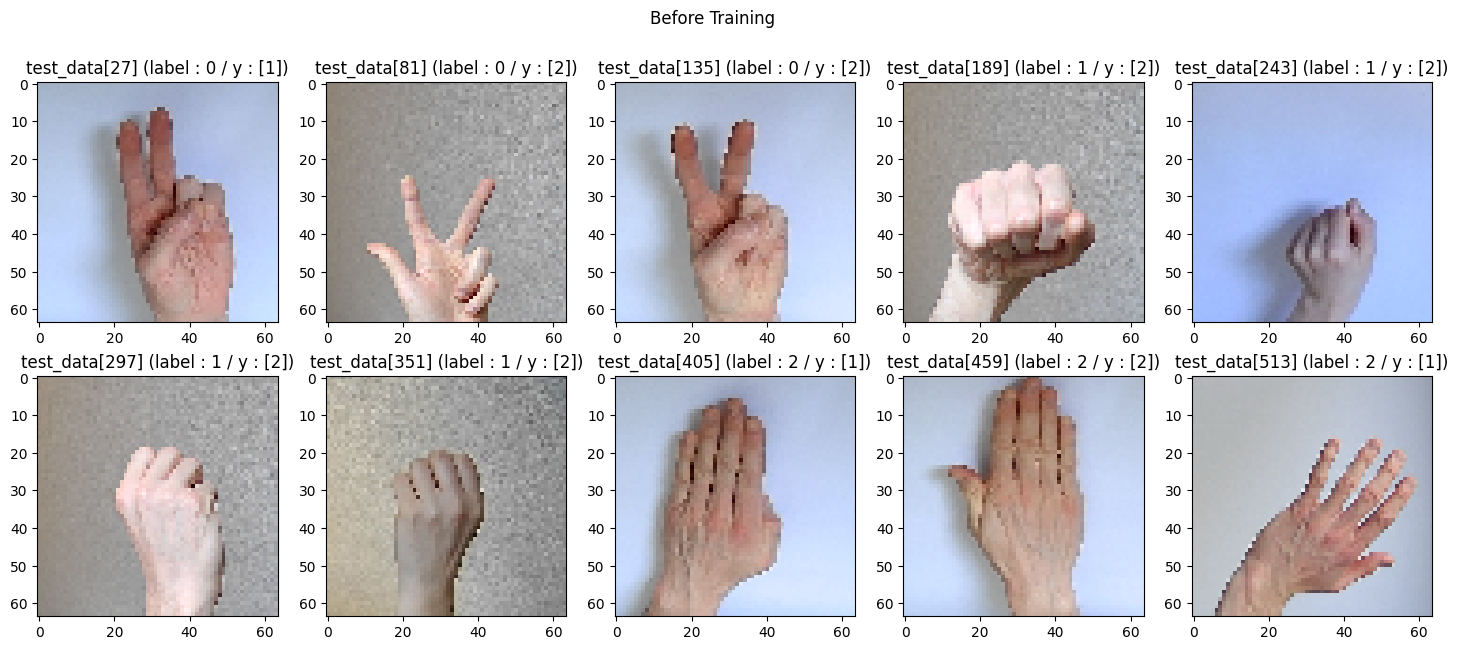

In [ ]:
# test_data에 들어 있는 테스트 이미지들을 모델에 넣어서 예측합니다.
#
# model.predict(test_data)는 test_data 전체에 대해 예측을 수행합니다.
# test_data가 100장이라면, 100장 각각에 대한 예측 결과가 나옵니다.
#
# 모델의 마지막 층이 Dense(3, activation='softmax')였기 때문에
# 각 이미지마다 3개 클래스에 대한 확률이 출력됩니다.
#
# 예를 들어 이미지 한 장에 대한 예측 결과가
# [0.1, 0.7, 0.2]라면
# 0번 클래스일 확률 10%
# 1번 클래스일 확률 70%
# 2번 클래스일 확률 20%
# 라는 뜻입니다.
y_out = model.predict(test_data)


# y_out에는 각 이미지마다 3개 클래스의 확률이 들어 있습니다.
#
# np.argmax(y_out, axis=1)는 각 이미지에서 가장 확률이 높은 클래스 번호를 찾습니다.
#
# axis=1은 한 이미지의 3개 확률 중에서 가장 큰 값을 찾겠다는 뜻입니다.
#
# 예를 들어 y_out이 아래와 같다면
# [
#   [0.1, 0.7, 0.2],
#   [0.8, 0.1, 0.1],
#   [0.2, 0.3, 0.5]
# ]
#
# np.argmax(y_out, axis=1)의 결과는
# [1, 0, 2]가 됩니다.
#
# 이유는 다음과 같습니다.
# 첫 번째 이미지는 1번 클래스 확률이 가장 큽니다.
# 두 번째 이미지는 0번 클래스 확률이 가장 큽니다.
# 세 번째 이미지는 2번 클래스 확률이 가장 큽니다.
#
# reshape((-1, 1))은 결과를 세로 형태로 바꾸는 코드입니다.
# 예를 들어 [1, 0, 2]를
# [[1],
#  [0],
#  [2]]
# 형태로 바꿉니다.
#
# -1은 데이터 개수는 파이썬이 알아서 맞추라는 뜻입니다.
# 1은 열을 1개로 만들겠다는 뜻입니다.
y_max = np.argmax(y_out, axis=1).reshape((-1, 1))


# 앞에서 만든 Make_Result_Plot 함수를 사용해서 예측 결과를 그림으로 보여줍니다.
#
# "Before Training"은 전체 그림의 제목입니다.
# 여기서는 학습 전 예측 결과를 보여주기 때문에 Before Training이라고 적었습니다.
#
# test_data는 화면에 보여줄 이미지 데이터입니다.
# test_labels는 실제 정답 라벨입니다.
# y_max는 모델이 예측한 라벨입니다.
#
# 이 함수를 실행하면 테스트 이미지 10장이 화면에 나오고,
# 각 이미지 위에 실제 정답 label과 모델 예측 y가 함께 표시됩니다.
Make_Result_Plot("Before Training", test_data, test_labels, y_max)

## 콜백 설정

In [21]:
# 저장할 모델 파일 이름을 정합니다.
# 여기서는 학습 중 가장 좋은 모델을
# RPS_PreTrained_DenseNet.keras 라는 이름으로 저장합니다.
#
# RPS는 Rock, Paper, Scissors의 약자로 볼 수 있습니다.
# 즉, 가위바위보 이미지 분류 모델이라는 의미입니다.
#
# .keras는 TensorFlow/Keras에서 권장하는 모델 저장 파일 형식입니다.
savedModelName = 'RPS_PreTrained_DenseNet.keras'


# callbacks는 모델 학습 중간에 자동으로 실행할 기능들을 모아 두는 리스트입니다.
# 쉽게 말하면, 학습 도중에 모델에게 시킬 추가 행동입니다.
#
# 예를 들어:
# 성능이 좋아지면 모델 저장하기
# 성능이 더 이상 좋아지지 않으면 학습 멈추기
# 학습률을 자동으로 줄이기
# 같은 기능을 넣을 수 있습니다.
callbacks = [

    # ModelCheckpoint는 학습 중 모델을 자동으로 저장해 주는 기능입니다.
    #
    # 학습을 여러 번 반복하다 보면 어떤 epoch에서는 성능이 좋고,
    # 어떤 epoch에서는 성능이 오히려 나빠질 수 있습니다.
    #
    # 그래서 매번 마지막 모델을 쓰는 것보다
    # 가장 성능이 좋았던 모델을 저장하는 것이 안전합니다.
    tf.keras.callbacks.ModelCheckpoint(

        # 모델을 저장할 파일 이름입니다.
        # 위에서 정한 savedModelName 값이 들어갑니다.
        savedModelName,

        # save_best_only=True는
        # 성능이 이전보다 좋아졌을 때만 모델을 저장하겠다는 뜻입니다.
        #
        # 예를 들어 validation loss가 가장 낮아지거나,
        # 설정된 기준 지표가 좋아졌을 때만 파일을 새로 저장합니다.
        #
        # 쉽게 말해, 학습 중 가장 좋은 모델만 남기고
        # 성능이 나쁜 모델은 저장하지 않습니다.
        save_best_only=True
    ),
    tfmot.sparsity.keras.UpdatePruningStep()
]

## 모델 학습

학습용 이미지 입력
→ 학습용 정답과 비교
→ 손실값 계산
→ Adam으로 가중치 수정
→ 이 과정을 30번 반복
→ 매 epoch마다 테스트 데이터로 검증
→ 가장 좋은 모델 자동 저장
→ 학습 기록을 history에 저장

In [22]:
%%time
# 이 셀 전체가 실행되는 데 걸린 시간을 측정합니다.
# Jupyter Notebook이나 Google Colab에서 사용하는 명령어입니다.
# 모델 학습 시간이 얼마나 걸렸는지 확인할 때 유용합니다.


# model.fit()은 실제로 모델을 학습시키는 함수입니다.
# 앞에서 model.compile()로 학습 방법을 정했다면,
# model.fit()은 데이터를 넣고 실제 학습을 시작하는 단계입니다.
history = model.fit(

    # train_data는 학습용 이미지 데이터입니다.
    # 예를 들어 가위바위보 이미지라면,
    # 모델은 이 이미지들을 보면서 특징을 학습합니다.
    train_data,

    # train_labels는 학습용 이미지의 정답 라벨입니다.
    # 예를 들어 0 = 바위, 1 = 보, 2 = 가위처럼
    # 각 이미지가 어떤 클래스인지 알려주는 정답입니다.
    train_labels,

    # epochs=30은 전체 학습 데이터를 30번 반복해서 학습한다는 뜻입니다.
    #
    # epoch는 전체 학습 데이터를 한 번 모두 보는 단위입니다.
    # 즉, epochs=30은 train_data 전체를 처음부터 끝까지 30번 반복해서 본다는 의미입니다.
    #
    # 너무 적으면 모델이 충분히 배우지 못할 수 있고,
    # 너무 많으면 학습 데이터를 외워서 새로운 이미지에 약해질 수 있습니다.
    epochs=30,

    # callbacks는 학습 도중 자동으로 실행할 기능입니다.
    #
    # 앞에서 ModelCheckpoint를 callbacks에 넣어 두었다면,
    # 학습 중 성능이 가장 좋은 모델을 자동으로 저장합니다.
    #
    # 즉, 30번 학습한 마지막 모델이 아니라,
    # 검증 성능이 가장 좋았던 시점의 모델을 파일로 남길 수 있습니다.
    callbacks=callbacks,

    # validation_data는 검증용 데이터입니다.
    #
    # train_data와 train_labels는 모델이 공부하는 데 사용하는 데이터이고,
    # test_data와 test_labels는 모델이 잘 배웠는지 확인하는 데 사용하는 데이터입니다.
    #
    # validation_data=(test_data, test_labels)는
    # 매 epoch가 끝날 때마다 test_data로 성능을 확인하겠다는 뜻입니다.
    #
    # 학습 데이터 정확도는 높은데 검증 데이터 정확도가 낮다면,
    # 모델이 학습 데이터를 외우는 과적합이 발생했을 가능성이 있습니다.
    validation_data=(test_data, test_labels)
)

Epoch 1/30


68/68 [==============================] - 61s 361ms/step - loss: 1.2827 - accuracy: 0.3582 - val_loss: 1.0507 - val_accuracy: 0.3505
Epoch 2/30
68/68 [==============================] - 18s 269ms/step - loss: 0.7830 - accuracy: 0.6312 - val_loss: 0.5414 - val_accuracy: 0.6881
Epoch 3/30
68/68 [==============================] - 18s 271ms/step - loss: 0.5321 - accuracy: 0.6971 - val_loss: 0.5191 - val_accuracy: 0.7963
Epoch 4/30
68/68 [==============================] - 20s 291ms/step - loss: 0.2761 - accuracy: 0.8872 - val_loss: 0.0918 - val_accuracy: 0.9780
Epoch 5/30
68/68 [==============================] - 20s 298ms/step - loss: 0.1291 - accuracy: 0.9567 - val_loss: 0.0546 - val_accuracy: 0.9817
Epoch 6/30
68/68 [==============================] - 20s 295ms/step - loss: 0.0839 - accuracy: 0.9742 - val_loss: 0.0480 - val_accuracy: 0.9835
Epoch 7/30
68/68 [==============================] - 20s 289ms/step - loss: 0.0771 - accuracy: 0.9784 - val_loss: 0.0148 - val_accuracy: 0.99

In [31]:
# Custom added
model.summary()

history.history.keys()
print(history.history.keys())

model_for_export = tfmot.sparsity.keras.strip_pruning(model)

model_for_export.save(
    "RPS_PreTrained_DenseNet_Pruned.keras"
)

model_for_export.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 64, 64, 3)]       0         
                                                                 
 tf.math.truediv_4 (TFOpLam  (None, 64, 64, 3)         0         
 bda)                                                            
                                                                 
 tf.nn.bias_add_2 (TFOpLamb  (None, 64, 64, 3)         0         
 da)                                                             
                                                                 
 tf.math.truediv_5 (TFOpLam  (None, 64, 64, 3)         0         
 bda)                                                            
                                                                 
 densenet121 (Functional)    (None, 2, 2, 1024)        7037504   
                                                           

In [30]:
print(history.history['accuracy'][-1])
print(history.history['val_accuracy'][-1])

print(history.history['loss'][-1])
print(history.history['val_loss'][-1])

1.0
0.9926605224609375
5.905538458250703e-08
0.030099760740995407


In [33]:
# Keras 모델 -> TFLite 변환
converter = tf.lite.TFLiteConverter.from_keras_model(
    model_for_export
)

tflite_model = converter.convert()


# 파일 저장
with open(
    "RPS_PreTrained_DenseNet_Pruning.tflite",
    "wb"
) as f:
    f.write(tflite_model)

print("Saved : RPS_PreTrained_DenseNet_Pruning.tflite")

INFO:tensorflow:Assets written to: C:\Users\ndong\AppData\Local\Temp\tmplykty687\assets


INFO:tensorflow:Assets written to: C:\Users\ndong\AppData\Local\Temp\tmplykty687\assets


Saved : RPS_PreTrained_DenseNet_Pruning.tflite


In [36]:
weights = model.layers[-1].layer.get_weights()[0]

print(weights.shape)

print(np.sum(weights == 0))
print(weights.size)
print(np.sum(weights == 0) / weights.size)

(1024, 3)
1536
3072
0.5


In [37]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "RPS_PreTrained_DenseNet_Pruned.keras"
)

converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open(
    "RPS_PreTrained_DenseNet_Pruned_Quant.tflite",
    "wb"
) as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\ndong\AppData\Local\Temp\tmp1rb9k10u\assets


INFO:tensorflow:Assets written to: C:\Users\ndong\AppData\Local\Temp\tmp1rb9k10u\assets


In [40]:
for t in tensor_details:
    if t["dtype"] != np.float32:
        print(
            t["name"],
            t["dtype"],
            t["shape"]
        )

model_2/global_average_pooling2d_2/Mean/reduction_indices <class 'numpy.int32'> [2]
model_2/densenet121/zero_padding2d_5/Pad/paddings <class 'numpy.int32'> [4 2]
model_2/densenet121/zero_padding2d_4/Pad/paddings <class 'numpy.int32'> [4 2]
model_2/densenet121/conv1/conv/Conv2D <class 'numpy.int8'> [64  7  7  3]
model_2/densenet121/conv2_block1_1_conv/Conv2D <class 'numpy.int8'> [128   1   1  64]
model_2/densenet121/conv2_block1_2_conv/Conv2D <class 'numpy.int8'> [ 32   3   3 128]
model_2/densenet121/conv2_block2_1_conv/Conv2D <class 'numpy.int8'> [128   1   1  96]
model_2/densenet121/conv2_block2_2_conv/Conv2D <class 'numpy.int8'> [ 32   3   3 128]
model_2/densenet121/conv2_block3_1_conv/Conv2D <class 'numpy.int8'> [128   1   1 128]
model_2/densenet121/conv2_block3_2_conv/Conv2D <class 'numpy.int8'> [ 32   3   3 128]
model_2/densenet121/conv2_block4_1_conv/Conv2D <class 'numpy.int8'> [128   1   1 160]
model_2/densenet121/conv2_block4_2_conv/Conv2D <class 'numpy.int8'> [ 32   3   3 128]

In [46]:
print(test_labels.shape)
print(test_labels[0])
print(type(test_labels[0]))

(545,)
0
<class 'numpy.int32'>


In [47]:
import tensorflow as tf
import numpy as np

def evaluate_tflite_model(model_path,
                          test_data,
                          test_labels):

    interpreter = tf.lite.Interpreter(
        model_path=model_path
    )

    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    input_dtype = input_details[0]["dtype"]

    correct = 0

    for i in range(len(test_data)):

        img = test_data[i:i+1]

        # INT8 모델
        if input_dtype == np.int8:

            scale, zero_point = \
                input_details[0]["quantization"]

            img = img / scale + zero_point

            img = np.round(img)

            img = np.clip(
                img,
                -128,
                127
            )

            img = img.astype(np.int8)

        # FLOAT32 모델
        else:
            img = img.astype(np.float32)

        interpreter.set_tensor(
            input_details[0]["index"],
            img
        )

        interpreter.invoke()

        output = interpreter.get_tensor(
            output_details[0]["index"]
        )

        pred = np.argmax(output)

        if pred == test_labels[i]:
            correct += 1

    return correct / len(test_labels)


acc_orig = evaluate_tflite_model(
    "RPS_PreTrained_DenseNet.tflite",
    test_data,
    test_labels
)

print(acc_orig)

acc_pruned = evaluate_tflite_model(
    "RPS_PreTrained_DenseNet_Pruning.tflite",
    test_data,
    test_labels
)

print(acc_pruned)

acc_quant = evaluate_tflite_model(
    "RPS_PreTrained_DenseNet_Pruned_Quant.tflite",
    test_data,
    test_labels
)


print(acc_quant)


0.9963302752293578
0.9926605504587156
0.9926605504587156


## Ploting : Cost/Training Count

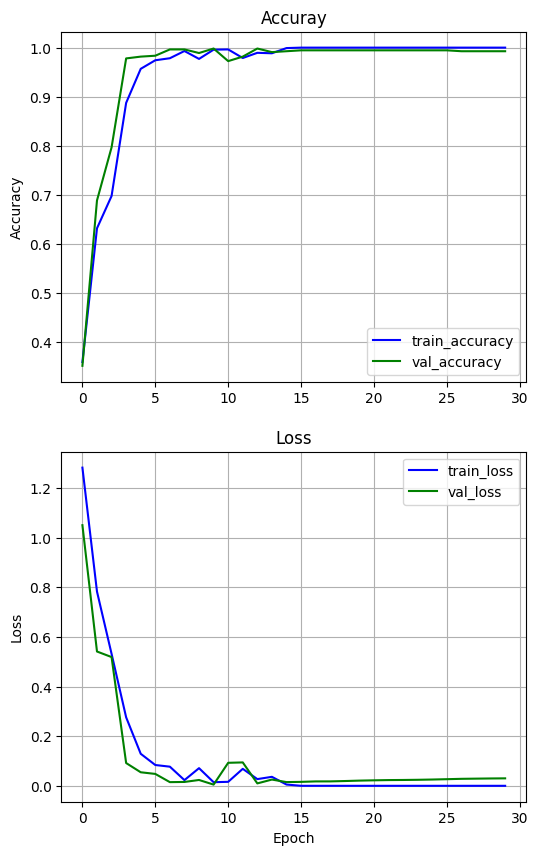

In [25]:
# 그래프 전체 크기를 설정합니다.
# figsize=(6, 10)은 가로 6, 세로 10 크기의 그림을 만든다는 뜻입니다.
# 세로로 긴 그림을 만드는 이유는
# 정확도 그래프와 손실 그래프를 위아래로 나누어 보여주기 위해서입니다.
plt.figure(figsize=(6, 10))


# 전체 그림을 2행 1열로 나누고,
# 그중 첫 번째 위치에 그래프를 그리겠다는 뜻입니다.
#
# 2, 1, 1의 의미:
# 2 = 그래프를 세로로 2개 배치
# 1 = 가로로는 1개만 배치
# 1 = 그중 첫 번째 칸을 사용
plt.subplot(2, 1, 1)


# 첫 번째 그래프의 제목을 설정합니다.
# 여기서는 정확도를 나타내는 그래프입니다.
# 오타가 하나 있습니다.
# 'Accuray'가 아니라 'Accuracy'가 맞습니다.
plt.title('Accuray')


# 학습 데이터의 정확도 변화를 그립니다.
#
# history.history['accuracy']에는
# epoch마다 학습 데이터에서 나온 정확도가 저장되어 있습니다.
#
# 예를 들어 epochs=30으로 학습했다면
# 정확도 값이 30개 들어 있습니다.
#
# 'b'는 파란색 선을 의미합니다.
# label='train_accuracy'는 범례에 표시될 이름입니다.
plt.plot(history.history['accuracy'], 'b', label='train_accuracy')


# 검증 데이터의 정확도 변화를 그립니다.
#
# history.history['val_accuracy']에는
# epoch마다 검증 데이터에서 나온 정확도가 저장되어 있습니다.
#
# 학습 정확도는 높은데 검증 정확도가 낮으면
# 모델이 학습 데이터만 외우고 있을 가능성이 있습니다.
#
# 'g'는 초록색 선을 의미합니다.
# label='val_accuracy'는 범례에 표시될 이름입니다.
plt.plot(history.history['val_accuracy'], 'g', label='val_accuracy')


# 그래프에 격자선을 표시합니다.
# 값의 변화를 눈으로 보기 쉽게 해 줍니다.
plt.grid(True)


# y축 이름을 Accuracy로 설정합니다.
# 정확도는 보통 0에서 1 사이의 값으로 표시됩니다.
# 예를 들어 0.95는 95% 정확도를 의미합니다.
plt.ylabel('Accuracy')


# 범례를 표시합니다.
# loc='best'는 그래프 안에서 가장 적절한 위치에 자동으로 배치하라는 뜻입니다.
plt.legend(loc='best')


# 전체 그림을 2행 1열로 나누고,
# 그중 두 번째 위치에 그래프를 그리겠다는 뜻입니다.
#
# 두 번째 그래프에는 손실값 변화를 표시합니다.
plt.subplot(2, 1, 2)


# 두 번째 그래프의 제목을 설정합니다.
# Loss는 모델이 얼마나 틀렸는지를 나타내는 값입니다.
plt.title('Loss')


# 학습 데이터의 손실값 변화를 그립니다.
#
# history.history['loss']에는
# epoch마다 학습 데이터에서 계산된 손실값이 저장되어 있습니다.
#
# 손실값은 낮을수록 좋습니다.
# 모델의 예측이 정답에 가까워질수록 loss는 줄어듭니다.
#
# 'b'는 파란색 선을 의미합니다.
plt.plot(history.history['loss'], 'b', label='train_loss')


# 검증 데이터의 손실값 변화를 그립니다.
#
# history.history['val_loss']에는
# epoch마다 검증 데이터에서 계산된 손실값이 저장되어 있습니다.
#
# train_loss는 계속 내려가는데 val_loss가 다시 올라간다면
# 과적합이 시작되었을 가능성이 큽니다.
#
# 'g'는 초록색 선을 의미합니다.
plt.plot(history.history['val_loss'], 'g', label='val_loss')


# 그래프에 격자선을 표시합니다.
plt.grid(True)


# x축 이름을 Epoch로 설정합니다.
# Epoch는 전체 학습 데이터를 몇 번째 반복해서 학습했는지를 의미합니다.
plt.xlabel('Epoch')


# y축 이름을 Loss로 설정합니다.
# Loss는 예측이 정답과 얼마나 차이 나는지를 나타내는 값입니다.
plt.ylabel('Loss')


# 범례를 표시합니다.
plt.legend(loc='best')


# 지금까지 만든 그래프를 화면에 출력합니다.
plt.show()

## best 모델 로딩 및 테스트

In [27]:
model_best = tf.keras.models.load_model(savedModelName)

18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 189ms/step


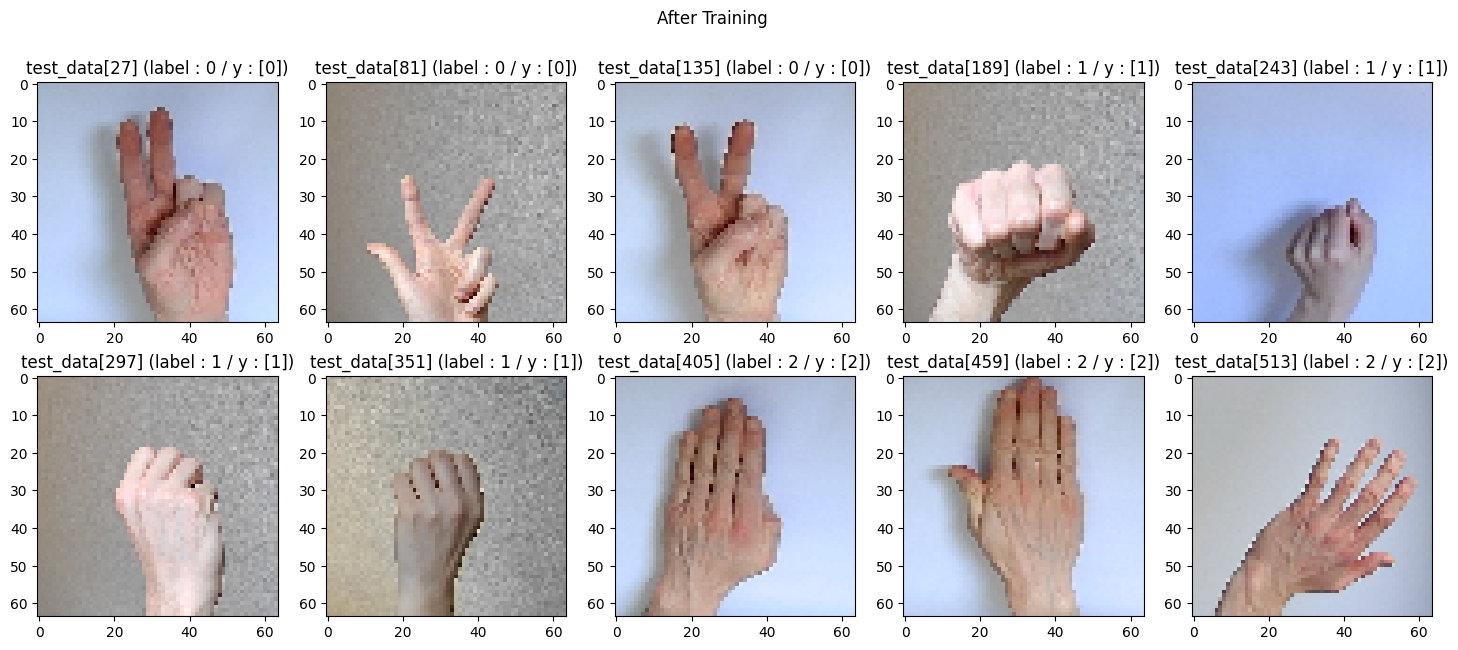

In [28]:
y_out = model_best.predict(test_data)
y_max = np.argmax(y_out, axis=1).reshape((-1, 1))
Make_Result_Plot("After Training", test_data, test_labels, y_max)

## best 모델 백업

In [29]:
from pathlib import Path

# 현재 실행 환경이 Google Colab인지 확인합니다.
# google.colab 모듈을 import할 수 있으면 Colab 환경이고,
# import할 수 없으면 VS Code, 로컬 PC, GCUBE, Jupyter 환경으로 판단합니다.
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False


# Colab에서 실행하는 경우
if IN_COLAB:
    # Google Drive를 Colab에 연결합니다.
    drive.mount('/content/drive')

    # Colab에서는 Google Drive 안에 결과를 저장합니다.
    save_dir = Path('/content/drive/MyDrive/files/save/')


# Colab이 아닌 환경에서 실행하는 경우
else:
    # VS Code, 로컬 PC, GCUBE, 일반 Jupyter에서는
    # 현재 노트북을 실행하는 폴더 아래에 files/save 폴더를 만듭니다.
    save_dir = Path('./files/save/')


# 저장 폴더가 없으면 자동으로 만듭니다.
# parents=True는 중간 폴더까지 함께 만들라는 뜻입니다.
# exist_ok=True는 이미 폴더가 있어도 오류를 내지 말라는 뜻입니다.
save_dir.mkdir(parents=True, exist_ok=True)

print("현재 실행 환경:", "Colab" if IN_COLAB else "Local / VS Code / GCUBE / Jupyter")
print("저장 폴더:", save_dir.resolve())

현재 실행 환경: Local / VS Code / GCUBE / Jupyter
저장 폴더: C:\Users\ndong\OneDrive\AI_Practice_2026_1\week14\files\save


In [30]:
from pathlib import Path

# savedModelName이 문자열(str)일 수도 있으므로 Path 객체로 변환합니다.
savedModelPath = Path(savedModelName)

# 저장 폴더와 저장 파일 확인
print("저장 폴더:", save_dir.resolve())
print("저장 모델:", savedModelPath.resolve())
print("저장 여부:", savedModelPath.exists())

저장 폴더: C:\Users\ndong\OneDrive\AI_Practice_2026_1\week14\files\save
저장 모델: C:\Users\ndong\OneDrive\AI_Practice_2026_1\week14\RPS_PreTrained_DenseNet.keras
저장 여부: True


In [31]:
# copy saved mode
cpCmd = f'cp {savedModelName} {save_dir}'
print(cpCmd)
!{cpCmd}

cp RPS_PreTrained_DenseNet.keras files\save


'cp'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


## LiteRT 모델로 변환

## TensorFlow Lite 원리와 성능 20줄 요약

TensorFlow Lite는 학습이 끝난 Keras 모델을 작은 장치에서 실행할 수 있도록 바꾸는 배포 기술이다.
Keras 모델은 학습과 실험에 적합하고, TensorFlow Lite 모델은 추론과 배포에 적합하다.
여기서 추론은 새로운 이미지를 보고 모델이 정답을 예측하는 과정이다.

`TFLiteConverter.from_keras_model(model_best)`는 Keras 모델을 TFLite로 변환할 준비를 하는 코드이다.

`converter.convert()`는 실제 변환을 수행해 `.tflite`로 저장할 수 있는 모델 데이터를 만든다.

기본 TFLite 변환은 모델을 더 똑똑하게 만드는 과정이 아니다.
이미 학습된 모델을 라즈베리파이, 스마트폰, 임베디드 보드에서 실행하기 좋은 형태로 바꾸는 과정이다.
기본 TFLite 변환은 학습 관련 정보와 불필요한 메타정보를 줄이고, 실행용 연산 그래프로 모델을 정리한다.
기본 변환만으로는 모델 크기가 크게 줄지 않을 수 있으며, 보통 0~30% 정도 감소를 기대할 수 있다.
모델 크기를 크게 줄이려면 TFLite 변환에 양자화를 함께 적용해야 한다.
양자화는 모델의 가중치 숫자 표현을 더 작은 단위로 줄이는 기술이다.
일반적인 딥러닝 가중치는 float32, 즉 32비트 실수로 저장된다.
INT8 양자화는 이 값을 8비트 정수 중심으로 바꾸는 방식이다.

32비트를 8비트로 줄이면 이론적으로 가중치 저장 크기는 약 4분의 1이 된다.
따라서 INT8 양자화는 약 70~75% 수준의 모델 크기 감소를 기대할 수 있다.
기본 TFLite 변환은 보통 정확도 변화가 거의 없지만, 실행 환경은 더 가벼워진다.
양자화를 적용하면 모델 크기와 추론 속도는 좋아질 수 있지만, 정확도는 소폭 떨어질 수 있다.
DenseNet121은 정확도는 좋을 수 있지만, 라즈베리파이 실시간 실행에는 다소 무거운 모델이다.
수업용 설명에는 DenseNet121 + TFLite 변환이 좋고, 실제 배포에는 MobileNet 계열 + TFLite 양자화가 더 적합하다.
최종 모델 선택은 정확도만이 아니라 파일 크기, 추론 속도, 라즈베리파이 FPS를 함께 비교해서 결정해야 한다.

In [32]:
from pathlib import Path
from datetime import datetime
import tensorflow as tf

# savedModelName이 문자열(str)이어도 Path 객체로 변환합니다.
savedModelPath = Path(savedModelName)

# 모델 파일이 실제로 존재하는지 먼저 확인합니다.
if not savedModelPath.exists():
    raise FileNotFoundError(f"모델 파일을 찾을 수 없습니다: {savedModelPath.resolve()}")

# 파일 정보 가져오기
file_stat = savedModelPath.stat()

# 생성 시간과 수정 시간 가져오기
# macOS / Windows에서는 st_birthtime이 생성 시간에 가깝습니다.
# Linux 환경에서는 st_birthtime이 없을 수 있으므로 수정 시간 기준으로 처리합니다.
try:
    created_time = datetime.fromtimestamp(file_stat.st_birthtime)
except AttributeError:
    created_time = None

modified_time = datetime.fromtimestamp(file_stat.st_mtime)

# 파일 크기 계산
file_size_mb = file_stat.st_size / (1024 * 1024)

# 모델 파일 정보 출력
print("불러올 모델 파일 정보")
print("-" * 50)
print("모델 경로:", savedModelPath.resolve())

if created_time is not None:
    print("생성 시간:", created_time.strftime("%Y-%m-%d %H:%M:%S"))
else:
    print("생성 시간: 이 환경에서는 확인 불가")

print("수정 시간:", modified_time.strftime("%Y-%m-%d %H:%M:%S"))
print("파일 크기:", f"{file_size_mb:.2f} MB")
print("-" * 50)

# 사용자에게 확인받기
answer = input("이 모델을 불러와서 TFLite로 변환할까요? 계속하려면 y를 입력하세요: ")

if answer.lower() == "y":
    # 사용자가 확인한 경우에만 best model을 불러옵니다.
    model_best = tf.keras.models.load_model(savedModelPath)

    print("Best model 불러오기 완료")

    # TFLite 변환기 생성
    converter = tf.lite.TFLiteConverter.from_keras_model(model_best)

    # TFLite 변환 실행
    tflite_model = converter.convert()

    # TFLite 저장 경로 설정
    tfliteModelName = savedModelPath.with_suffix(".tflite")

    # 변환된 TFLite 모델 저장
    with open(tfliteModelName, "wb") as f:
        f.write(tflite_model)

    print("TFLite 변환 완료")
    print("TFLite 저장 위치:", tfliteModelName.resolve())

else:
    print("작업을 취소했습니다. 모델을 불러오지 않았습니다.")

불러올 모델 파일 정보
--------------------------------------------------
모델 경로: C:\Users\ndong\OneDrive\AI_Practice_2026_1\week14\RPS_PreTrained_DenseNet.keras
생성 시간: 이 환경에서는 확인 불가
수정 시간: 2026-06-01 14:37:53
파일 크기: 81.64 MB
--------------------------------------------------
Best model 불러오기 완료
INFO:tensorflow:Assets written to: C:\Users\ndong\AppData\Local\Temp\tmpqb_opjro\assets


INFO:tensorflow:Assets written to: C:\Users\ndong\AppData\Local\Temp\tmpqb_opjro\assets


Saved artifact at 'C:\Users\ndong\AppData\Local\Temp\tmpqb_opjro'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2740966156144: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2740966150688: TensorSpec(shape=(3,), dtype=tf.float32, name=None)
  2740967990272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2740968050176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2740968052288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2740967996256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2740968047888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2740968060208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2740968056336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2740968060384: TensorSpec(shape=(), dtype=tf.resource, name=None

## LiteRT 모델을 파일로 저장


In [33]:
from pathlib import Path
from datetime import datetime

# 비교할 파일 경로 설정
# savedModelName이 이미 .keras 파일 경로라면 그대로 사용합니다.
keras_path = Path(savedModelName)

# .keras 파일과 같은 이름의 .tflite 파일 경로를 만듭니다.
# 예: RPS_PreTrained_DenseNet.keras → RPS_PreTrained_DenseNet.tflite
tflite_path = keras_path.with_suffix(".tflite")


# 파일 정보를 보기 좋게 출력하는 함수
def print_file_info(title, file_path):
    file_path = Path(file_path)

    print(f"\n[{title}]")

    if not file_path.exists():
        print("파일 없음:", file_path.resolve())
        return None

    stat = file_path.stat()

    # 파일 크기
    size_mb = stat.st_size / (1024 * 1024)

    # 수정 시간
    modified_time = datetime.fromtimestamp(stat.st_mtime)

    # 생성 시간
    # macOS / Windows에서는 st_birthtime이 있을 수 있습니다.
    # Linux / Colab / 일부 서버에서는 없을 수 있습니다.
    try:
        created_time = datetime.fromtimestamp(stat.st_birthtime)
        created_text = created_time.strftime("%Y-%m-%d %H:%M:%S")
    except AttributeError:
        created_text = "이 환경에서는 생성 시간 확인 불가"

    print("파일 경로:", file_path.resolve())
    print("파일 크기:", f"{size_mb:.2f} MB")
    print("생성 시간:", created_text)
    print("수정 시간:", modified_time.strftime("%Y-%m-%d %H:%M:%S"))

    return size_mb


# Before: Keras 모델 정보
keras_size = print_file_info("Before: Keras 모델", keras_path)

# After: TFLite 모델 정보
tflite_size = print_file_info("After: TFLite 모델", tflite_path)


# 크기 감소율 계산
if keras_size is not None and tflite_size is not None:
    reduction = (1 - tflite_size / keras_size) * 100

    print("\n[크기 비교 결과]")
    print("Keras 모델 크기:", f"{keras_size:.2f} MB")
    print("TFLite 모델 크기:", f"{tflite_size:.2f} MB")
    print("크기 감소율:", f"{reduction:.2f}%")


[Before: Keras 모델]
파일 경로: C:\Users\ndong\OneDrive\AI_Practice_2026_1\week14\RPS_PreTrained_DenseNet.keras
파일 크기: 81.64 MB
생성 시간: 이 환경에서는 생성 시간 확인 불가
수정 시간: 2026-06-01 14:37:53

[After: TFLite 모델]
파일 경로: C:\Users\ndong\OneDrive\AI_Practice_2026_1\week14\RPS_PreTrained_DenseNet.tflite
파일 크기: 26.64 MB
생성 시간: 이 환경에서는 생성 시간 확인 불가
수정 시간: 2026-06-01 14:45:23

[크기 비교 결과]
Keras 모델 크기: 81.64 MB
TFLite 모델 크기: 26.64 MB
크기 감소율: 67.37%
